# Modelos ARIMA

Neste Notebook, avança-se no estudo de séries temporais utilizando o modelo ARIMA.

## Objetivos:
- Entender o modelo ARIMA (p, d, q)
- Aplicar diferenciação para tornar séries estacionárias
- Analisar ACF e PACF
- Ajustar um modelo ARIMA em dados simulados

## pré-requisito:
- Notebook 01 (fundamentos)

In [1]:
#Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

#Configurações
plt.style.use('dark_background')
np.random.seed(42)

## O que é ARIMA?

ARIMA significa:
- AR (AutoRegressive) $\rightarrow$ p
- I  (Integrated / Diferenciação) $\rightarrow$ d
- MA (Moving Avarage) $\rightarrow$ q

### Notação:
ARIMA(p, d, q)

Onde:
- p = número de termos autoregressivos
- d = número de diferenciações
- q = número de termos de média móvel

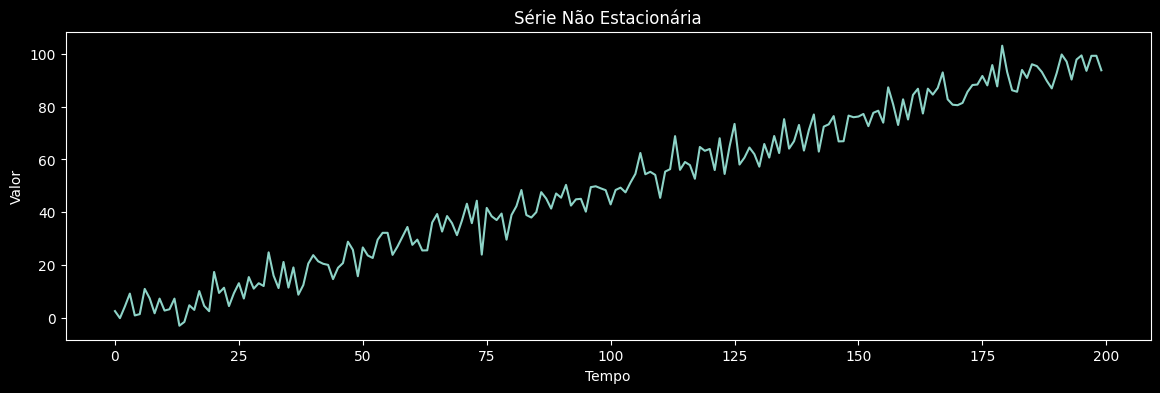

In [2]:
n = 200
tempo = np.arange(n)

#Série com tendência (não estacionária)
serie = 0.5 * tempo + np.random.normal(0, 5, n)

plt.figure(figsize=(14, 4))
plt.plot(tempo, serie)
plt.title("Série Não Estacionária")
plt.xlabel("Tempo")
plt.ylabel("Valor")
plt.show()

In [3]:
# Teste ADF
def teste_adf(serie, nome):
    resultado = adfuller(serie)
    print(f"--- {nome} ---")
    print(f"Estatística ADF: {resultado[0]:.4f}")
    print(f"p-valor: {resultado[1]:.4f}")
    print()

teste_adf(serie, "Série Original")

--- Série Original ---
Estatística ADF: -0.0684
p-valor: 0.9525



## Diferenciação (d)

A diferenciação remove tendências e torna a série estacionária.

Fórmula:

$X^{'}_t = X_t - X_{t-1}$

Podemos aplicar múltiplas vezes (d = 1, 2, ...)

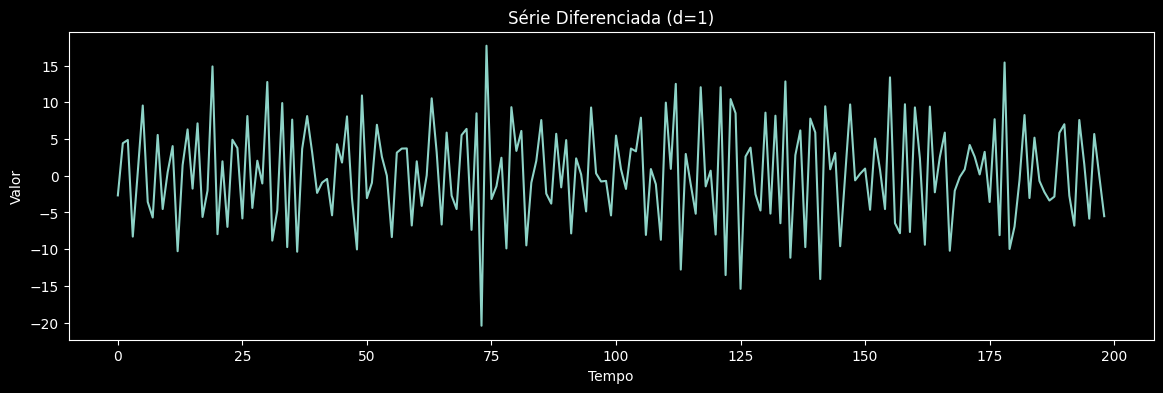

--- Série Diferenciada ---
Estatística ADF: -7.6620
p-valor: 0.0000



In [4]:
# Aplicando Diferenciação
serie_diff = np.diff(serie)

plt.figure(figsize=(14, 4))
plt.plot(serie_diff)
plt.title("Série Diferenciada (d=1)")
plt.xlabel("Tempo")
plt.ylabel("Valor")
plt.show()

teste_adf(serie_diff, "Série Diferenciada")

## ACF e PACF

### ACF (Auocorrelation Function)
- Mede correlação com valores passados

### PACF (Partial Autocorrelation Function)
- Mede correlação direta, removendo feitos intermediários

### Intuição:
- AR(p) $\rightarrow$ PACF corta após lag p
- MA(q) $\rightarrow$ ACF corta após lag q

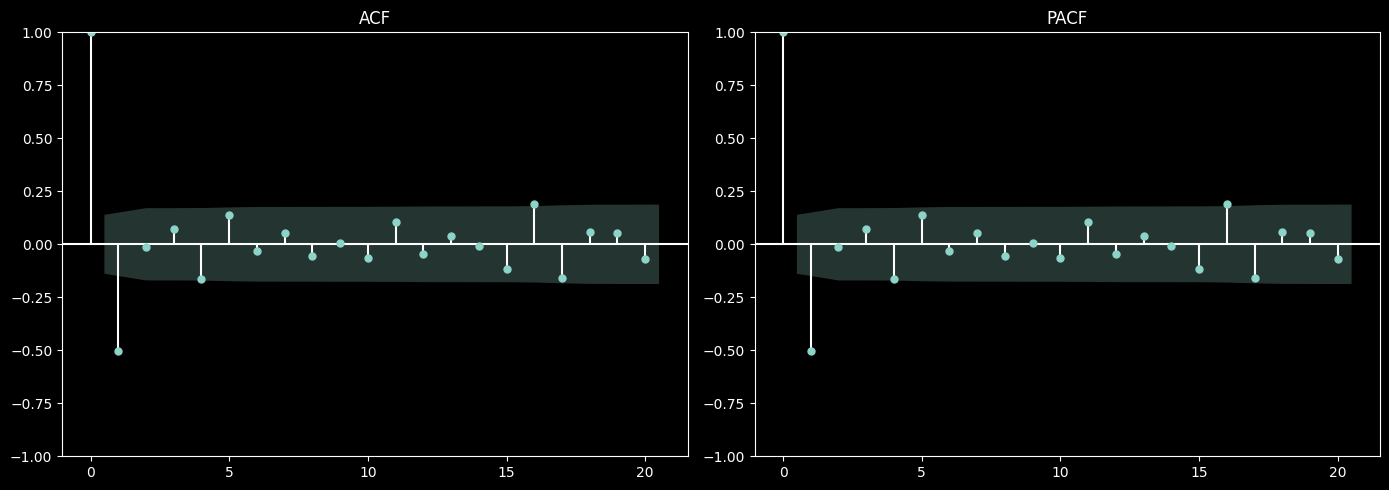

In [7]:
# Plotando ACFe PACF
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plot_acf(serie_diff, ax=plt.gca(), lags=20)
plt.title("ACF")

plt.subplot(1, 2, 2)
plot_acf(serie_diff, ax=plt.gca(), lags=20)
plt.title("PACF")

plt.tight_layout()
plt.show()

## Escolhendo (p, d, q)

Com base nos gráficos:
- d = número de diferenciações necesárias
- p = onde PACF corta
- q = onde ACF corta

*OBS: Isso é heurístico (regra prática)*

In [8]:
# Ajustando modelo ARIMA
#Exemplo: ARIMA(1,1,1)
modelo = ARIMA(serie, order=(1, 1, 1))
resultado = modelo.fit()

print(resultado.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  200
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -615.443
Date:                Wed, 25 Mar 2026   AIC                           1236.886
Time:                        21:20:58   BIC                           1246.766
Sample:                             0   HQIC                          1240.885
                                - 200                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1086      0.104     -1.040      0.298      -0.313       0.096
ma.L1         -0.6647      0.080     -8.315      0.000      -0.821      -0.508
sigma2        28.3263      2.958      9.576      0.0

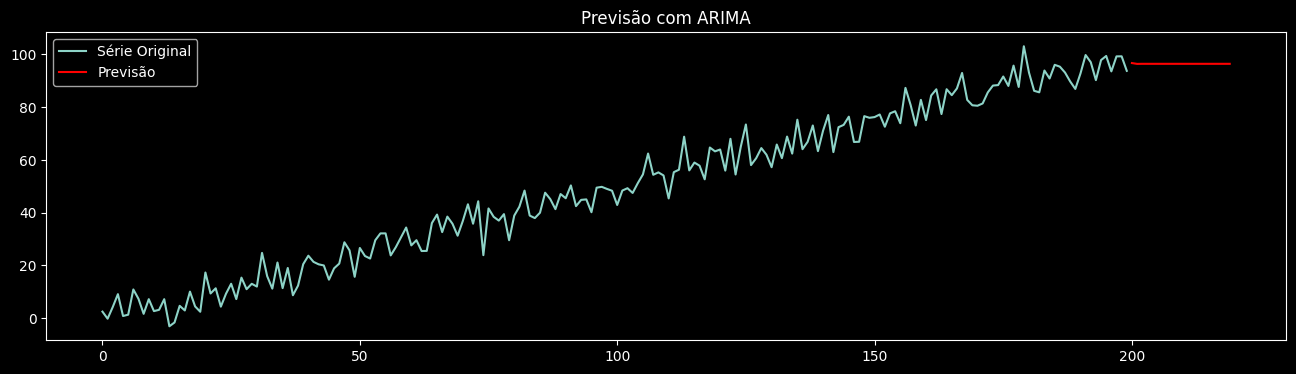

In [10]:
#Previsão
previsoes = resultado.forecast(steps=20)

plt.figure(figsize=(16, 4))
plt.plot(serie, label="Série Original")
plt.plot(range(len(serie), len(serie)+20), previsoes, label="Previsão", color='red')
plt.legend()
plt.title("Previsão com ARIMA")
plt.show()

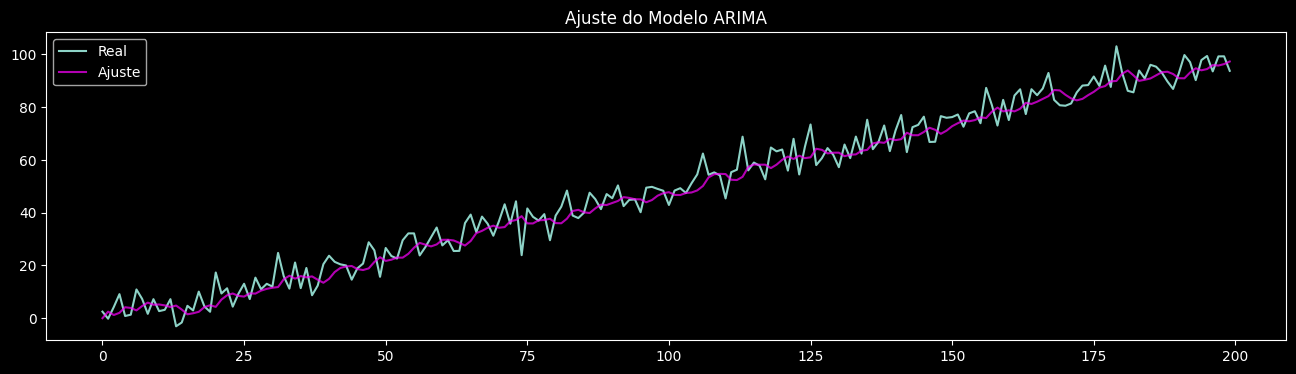

In [13]:
# Compração Ajuste vs Real
ajuste = resultado.fittedvalues

plt.figure(figsize=(16, 4))
plt.plot(serie, label="Real")
plt.plot(ajuste, label="Ajuste", alpha=0.7, color='magenta')
plt.legend()
plt.title("Ajuste do Modelo ARIMA")
plt.show()

## Conclusão

Neste notebook, aprendeu-se:

- O que é o modelo ARIMA
- Como tornar séries estacionárias (diferenciação)
- Como interpretar ACF e PACF
- Como ajustar um modelo ARIMA
- Como fazer previsões

## Próximos passos:

Extensão para múltiplas séries:
- VAR (Vector AutoRegression)
- VARMAX (modelo alvo do projeto)

No próximo notebook:

*VAR - Modelos Multivariados*